In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder

from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM

In [2]:
torch.cuda.is_available()

False

In [18]:
# loading and preprocessing data
data = pd.read_json("CDs_and_Vinyl.jsonl", lines=True)

In [19]:
data = data[data["rating"] != 3]

In [20]:
data = data[data["timestamp"] > "2015-01-01"]

In [21]:
data["year"] = data["timestamp"].apply(lambda x: x.year)
data["month"] = data["timestamp"].apply(lambda x: x.month)
data["day"] = data["timestamp"].apply(lambda x: x.day)

In [16]:
len(data)

2255468

In [22]:
# binarization of reviews to train ctr-predictor
data["rating"] = data["rating"].transform(lambda x: 1 if x > 3 else 0)

In [65]:
data.to_json("ml_data.json")

In [15]:
data.set_index(data["timestamp"], inplace=True)

In [16]:
data.sort_index(inplace=True)

<Axes: xlabel='timestamp'>

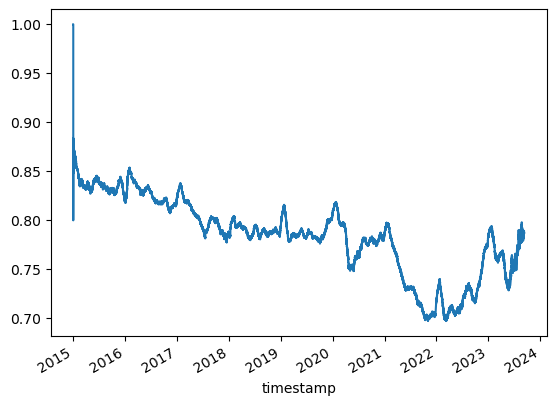

In [17]:
data["rating"].rolling("30D").mean().plot()

In [23]:
# code based on an example in the deepctr-torch documentation
# generates a ctr-prediction model


def split(x):
    key_ans = x.split("|")
    for key in key_ans:
        if key not in key2index:
            # Notice : input value 0 is a special "padding",so we do not use 0 to encode valid feature for sequence input
            key2index[key] = len(key2index) + 1
    return list(map(lambda x: key2index[x], key_ans))


if __name__ == "__main__":
    sparse_features = ["parent_asin", "user_id", "year", "month", "day"]
    target = ["rating"]

    # 1.Label Encoding for sparse features,and process sequence features
    for feat in sparse_features:
        lbe = LabelEncoder()
        data[feat] = lbe.fit_transform(data[feat])
    # preprocess the sequence feature

    # 2.count #unique features for each sparse field and generate feature config for sequence feature
    fixlen_feature_columns = []
    fixlen_feature_columns.append(SparseFeat("parent_asin", 2255468, embedding_dim=8))
    fixlen_feature_columns.append(SparseFeat("user_id", 2255468, embedding_dim=8))
    fixlen_feature_columns.append(SparseFeat("year", 10000, embedding_dim=8))
    fixlen_feature_columns.append(SparseFeat("month", 20, embedding_dim=8))
    fixlen_feature_columns.append(SparseFeat("day", 40, embedding_dim=8))

    linear_feature_columns = fixlen_feature_columns
    dnn_feature_columns = fixlen_feature_columns

    feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)
    data_sample = data

    # 3.generate input data for model
    model_input = {name: data_sample[name] for name in sparse_features}

    # 4.Define Model,compile and train

    device = "cpu"
    use_cuda = True
    if use_cuda and torch.cuda.is_available():
        print("cuda ready...")
        device = "cuda:0"

    model = DeepFM(
        linear_feature_columns, dnn_feature_columns, task="binary", device=device
    )

    model.compile("adam", metrics=["AUC"], loss="binary_crossentropy")
    history = model.fit(
        model_input,
        data_sample[target].values,
        batch_size=1024,
        epochs=6,
        verbose=2,
        validation_split=0.1,
    )

cpu
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch
Epoch 1/6
1006s - loss:  0.4865
Epoch 2/6
1059s - loss:  0.1399
Epoch 3/6
6548s - loss:  0.0739
Epoch 4/6
2650s - loss:  0.0407
Epoch 5/6
1072s - loss:  0.0233
Epoch 6/6
1129s - loss:  0.0169


In [ ]:
# testing the model

In [63]:
test_data = {
    "user_id": pd.Series([1615322]),
    "parent_asin": pd.Series([17530]),
    "year": pd.Series([18]),
    "month": pd.Series([4]),
    "day": pd.Series([1]),
}

In [48]:
model.predict(model_input)

array([[0.99978966],
       [0.9999783 ],
       [0.99996603],
       ...,
       [0.99994683],
       [0.95628232],
       [0.0896687 ]])

In [49]:
np.mean(model.predict(model_input))

0.7626499902568948

In [64]:
model.predict(test_data)

array([[0.02575172]])

In [24]:
# saving the model
torch.save(model, "./model_formatted_fashion_cpu_v2")

In [64]:
# loading a different model
new_model = torch.load("./model")